In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Multi-Station QC Evaluation

This notebook loads hourly observations for three stations, converts them to daily values, and runs the modular QC flow for each station. The station selection uses the shared SQL query for network 2 and the requested variables.

In [38]:
import os
import sys
import pandas as pd
import numpy as np
import sqlalchemy as sa
from sqlalchemy.orm import Session
# Make the function folder and package root available
sys.path.append(os.path.abspath('./func/'))
sys.path.append(os.path.abspath('../../'))


save_path = './comparison_forms/'
db_url = "postgresql://tongli1997@db.pcic.uvic.ca:5433/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"
engine = sa.create_engine(db_url, echo=False)
session = Session(engine)
session

In [39]:
from visualizaion_func import *

In [54]:
# replace with the three station IDs you want to evaluate
station_id = [2926]

sql_text = sa.text(
    """
SELECT s.station_id, o.obs_time, v.net_var_name, o.datum
FROM meta_history h
JOIN meta_station s ON h.station_id = s.station_id
JOIN obs_raw o ON o.history_id = h.history_id
JOIN meta_vars v ON o.vars_id = v.vars_id
WHERE s.network_id = 2
AND s.station_id IN :stations
AND v.net_var_name IN (
    'MINIMUM_AIR_TEMPERATURE',
    'MAXIMUM_AIR_TEMPERATURE',
    'min_air_temp_snc_last_reset',
    'max_air_temp_snc_last_reset',
    'air_temp',
    'pcpn_amt_pst1hr',
    'snwfl_amt_pst1hr',
    'snw_dpth'
)
ORDER BY s.station_id, o.obs_time
""")

with engine.begin() as conn:
    df_station = pd.read_sql(sql_text, conn, params={
        "stations": tuple(station_id)})

print("Loaded observations for",
      df_station["station_id"].nunique(), "stations")
print(df_station.head())

Loaded observations for 1 stations
   station_id            obs_time             net_var_name  datum
0        2926 2008-07-16 12:00:00  MAXIMUM_AIR_TEMPERATURE  6.514
1        2926 2008-07-16 12:00:00  MINIMUM_AIR_TEMPERATURE  4.135
2        2926 2008-07-16 13:00:00  MINIMUM_AIR_TEMPERATURE  4.135
3        2926 2008-07-16 13:00:00  MAXIMUM_AIR_TEMPERATURE  6.835
4        2926 2008-07-16 14:00:00  MAXIMUM_AIR_TEMPERATURE  7.060


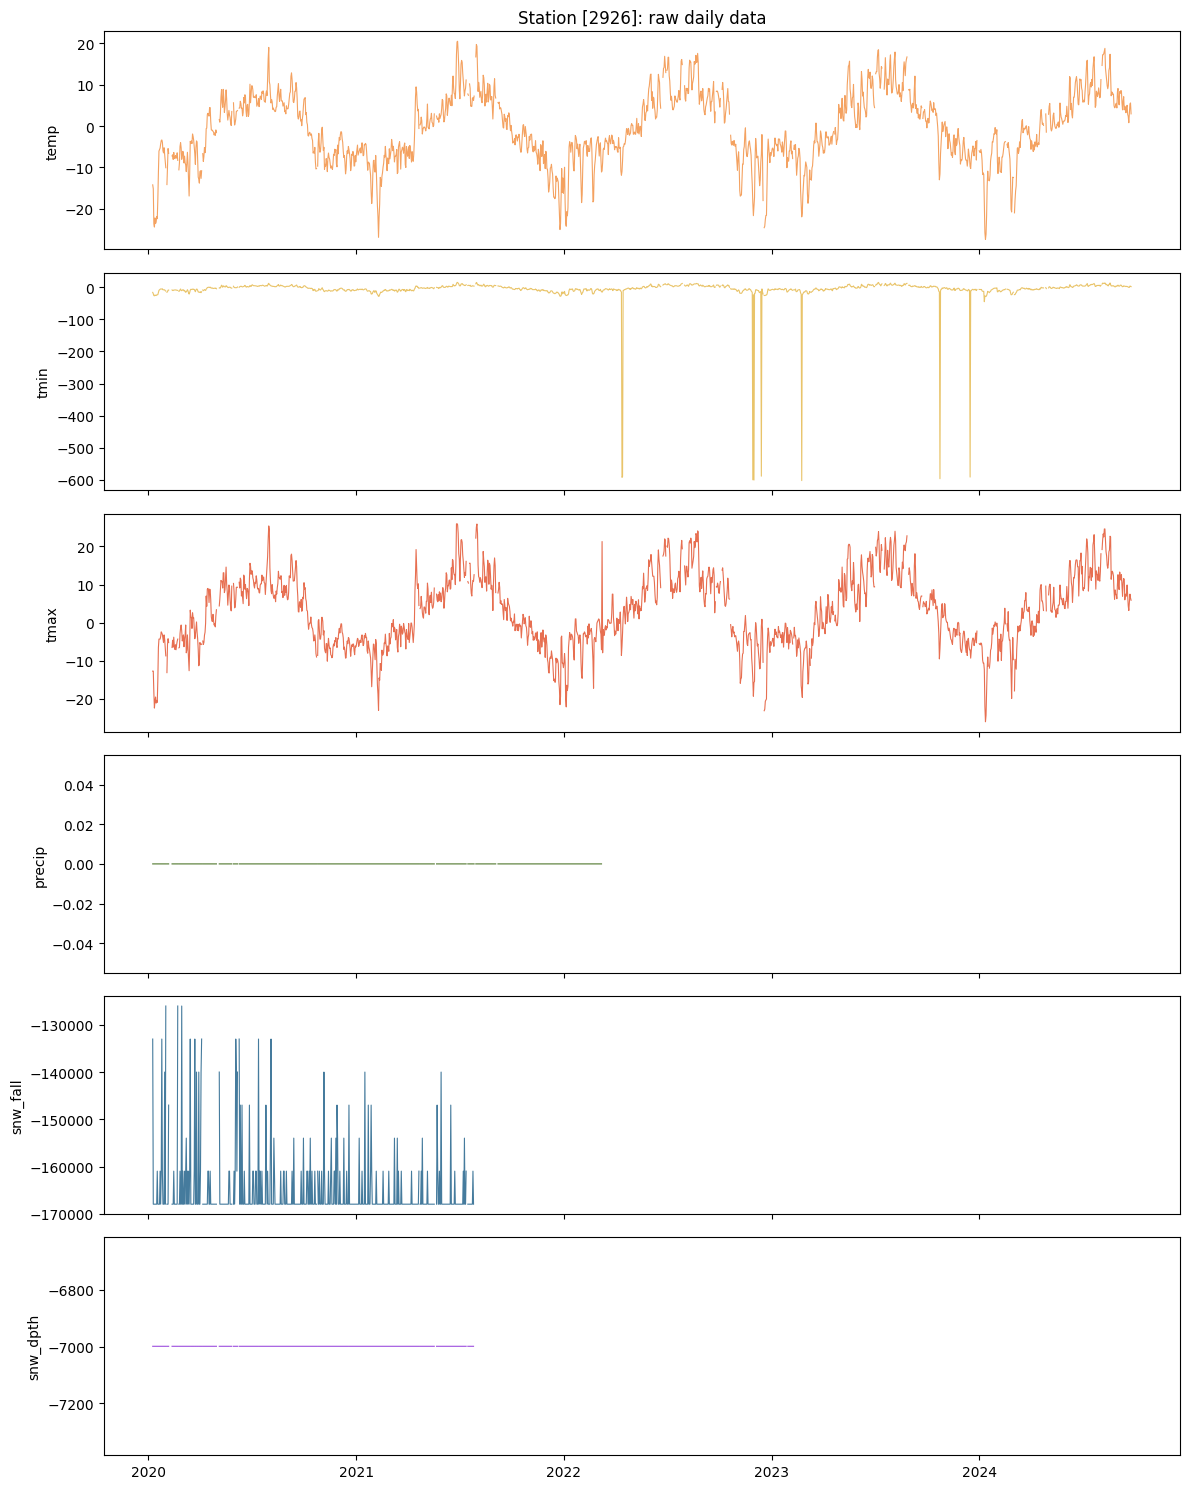

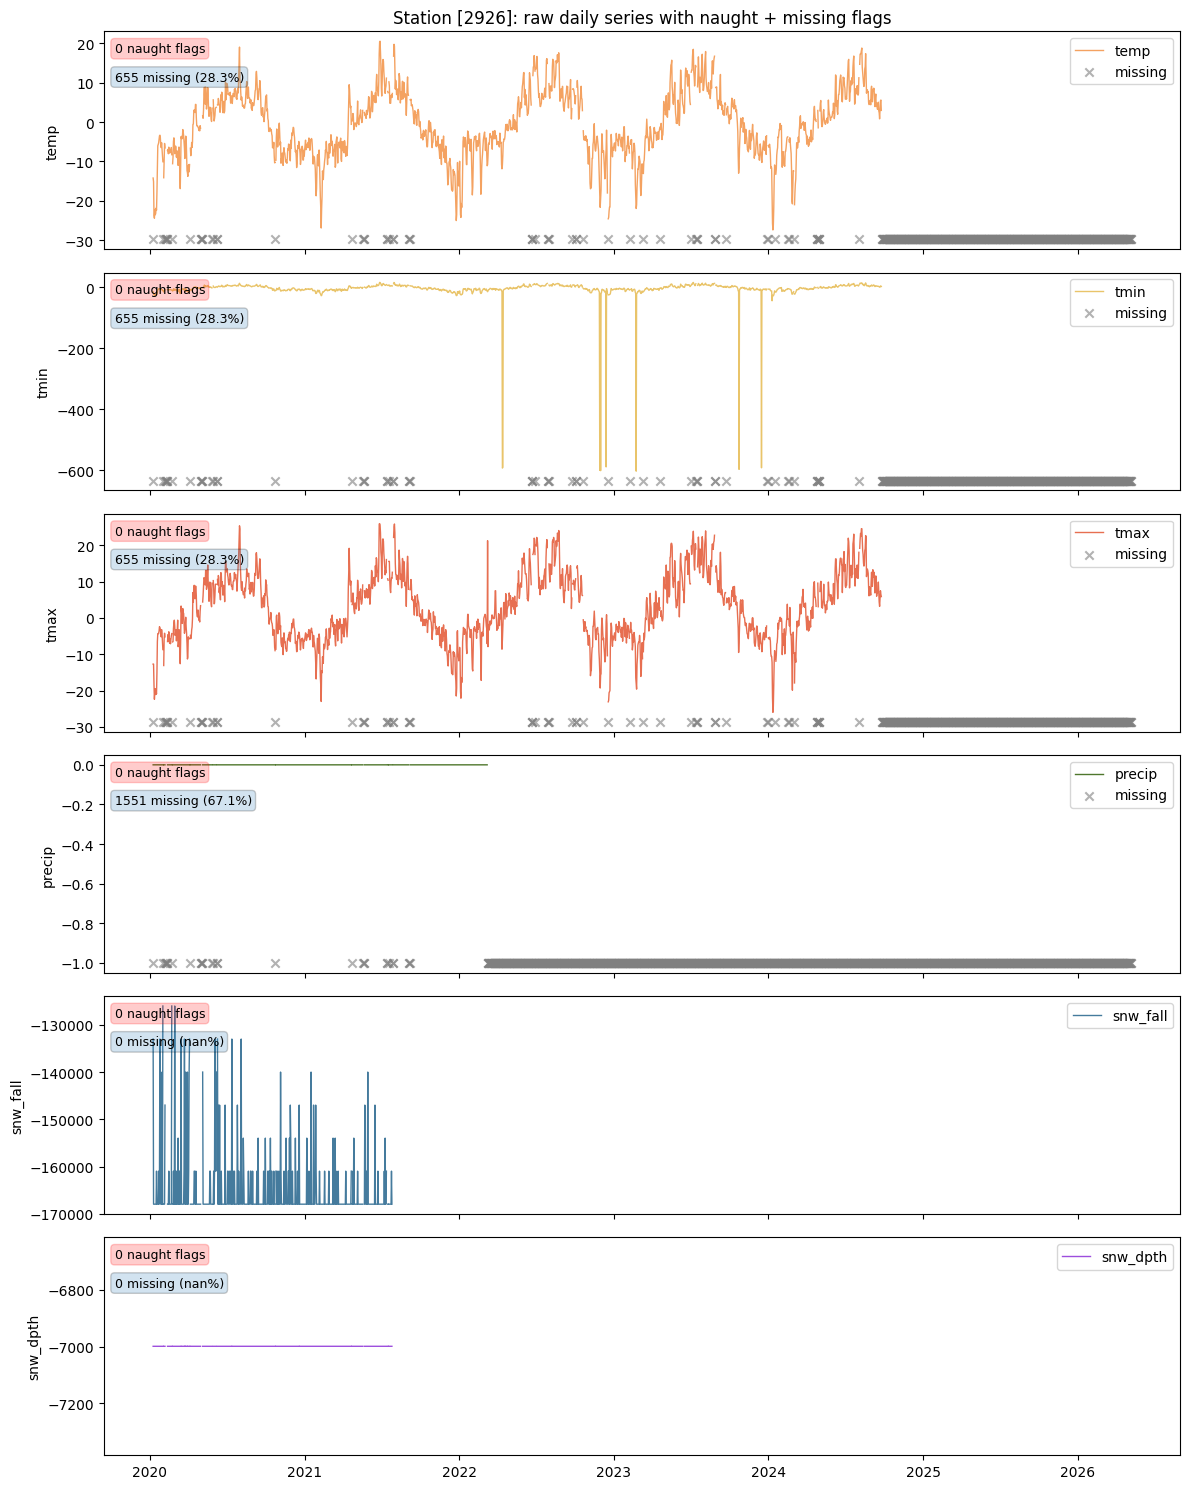

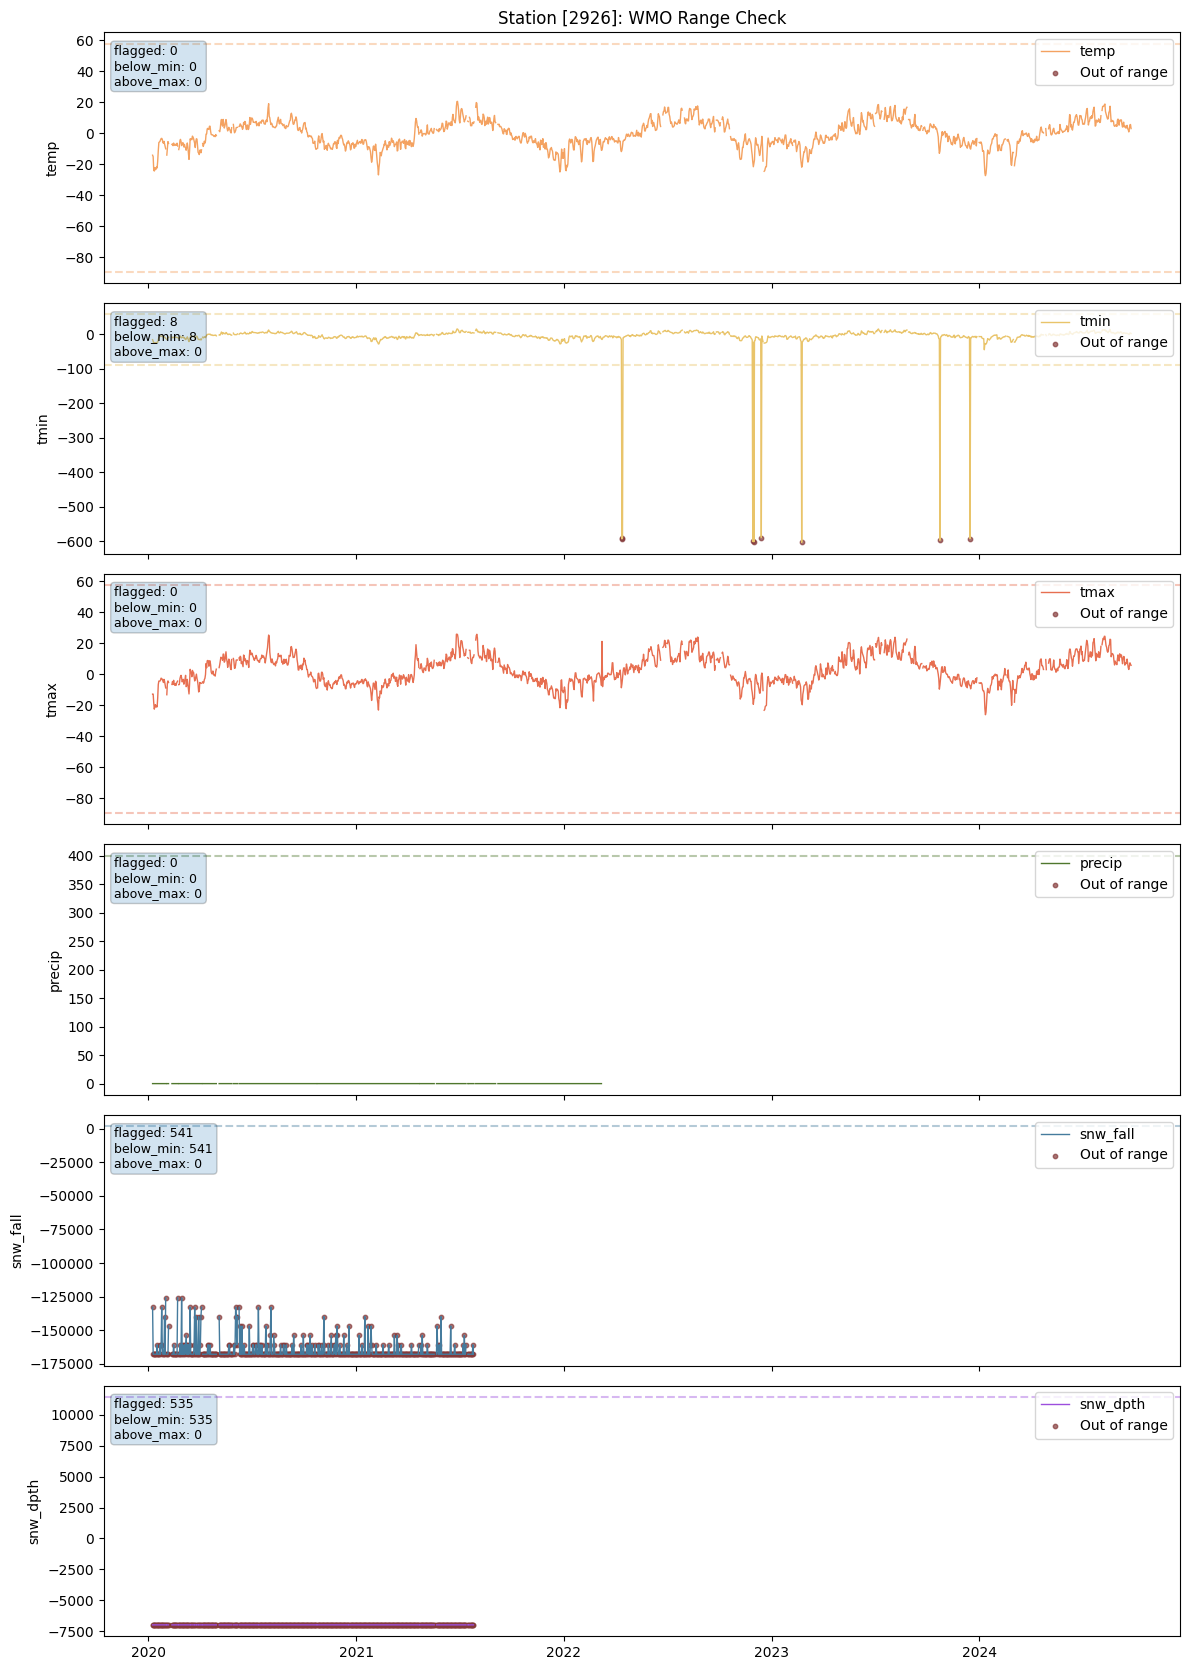

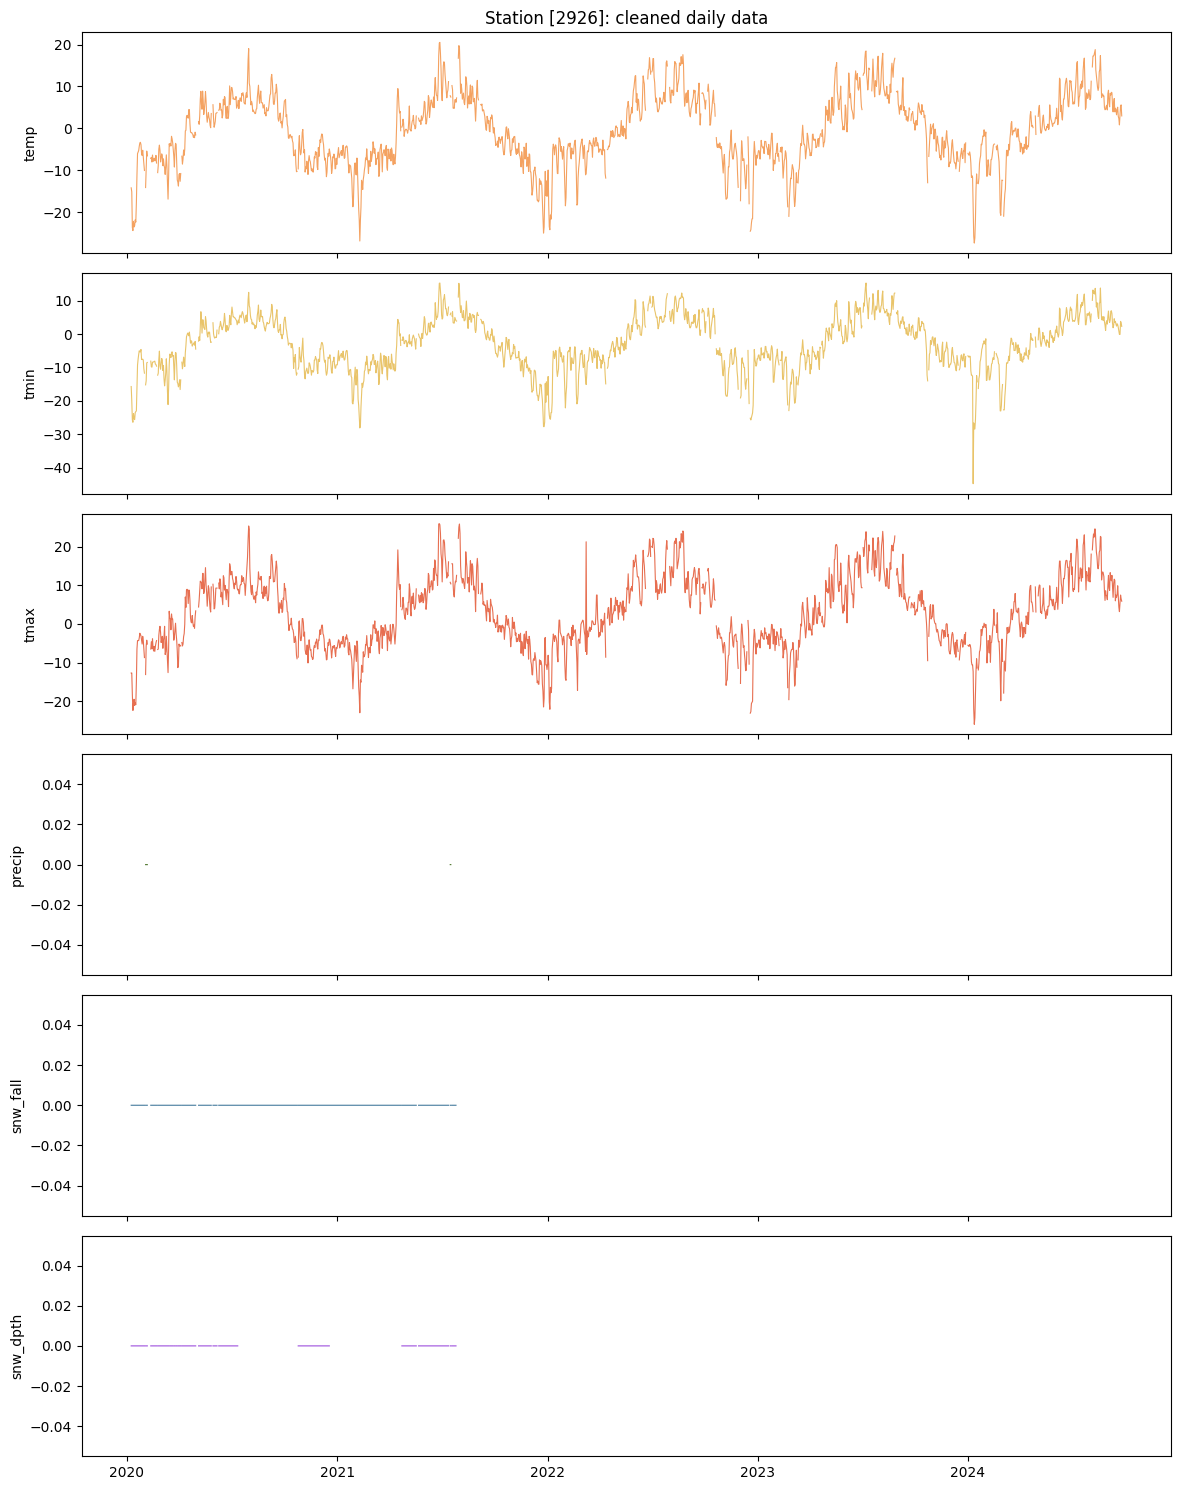

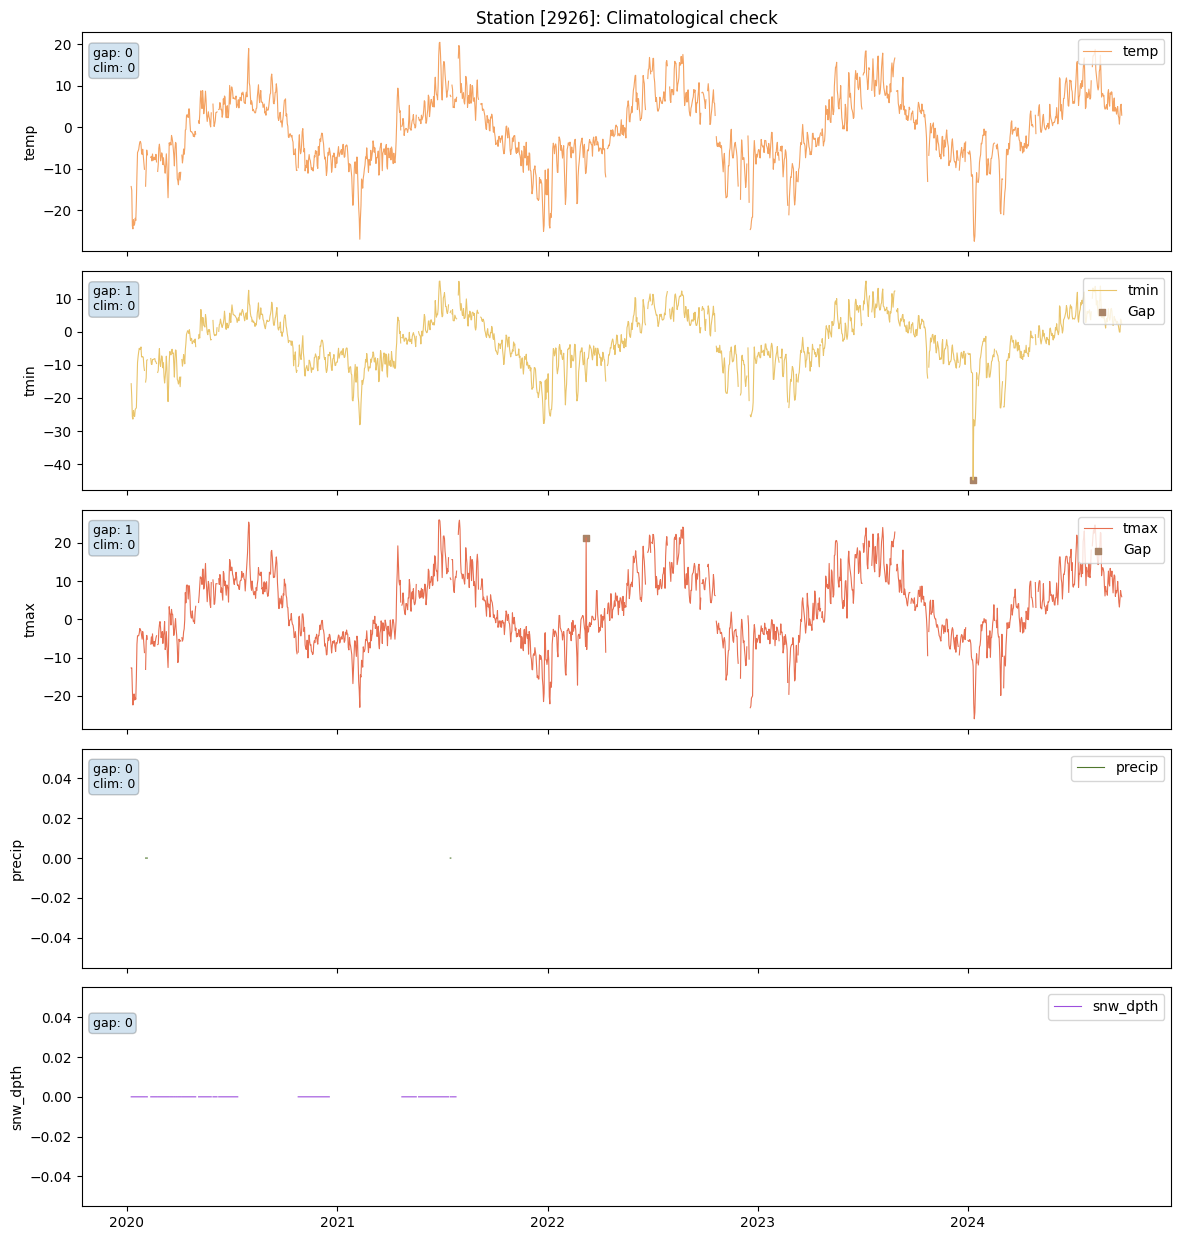

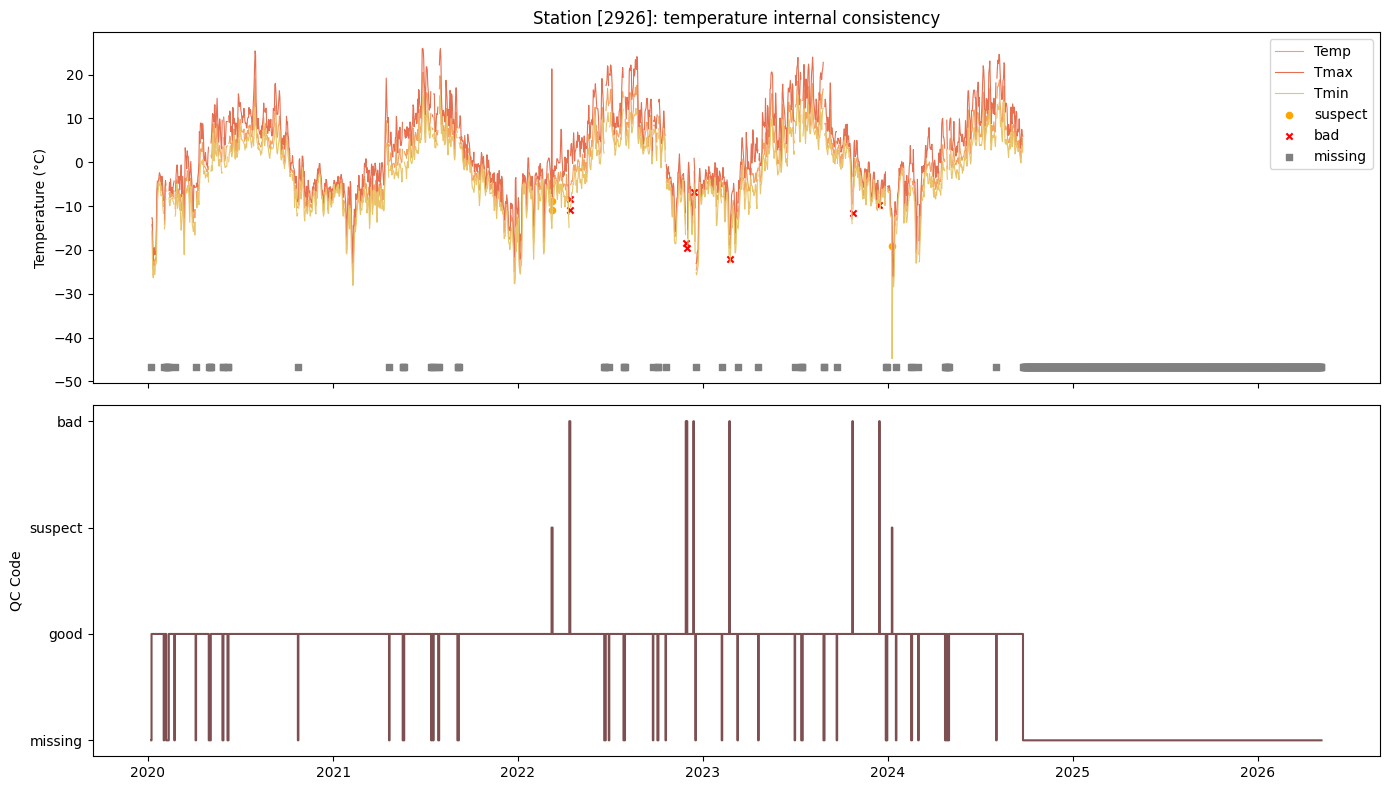

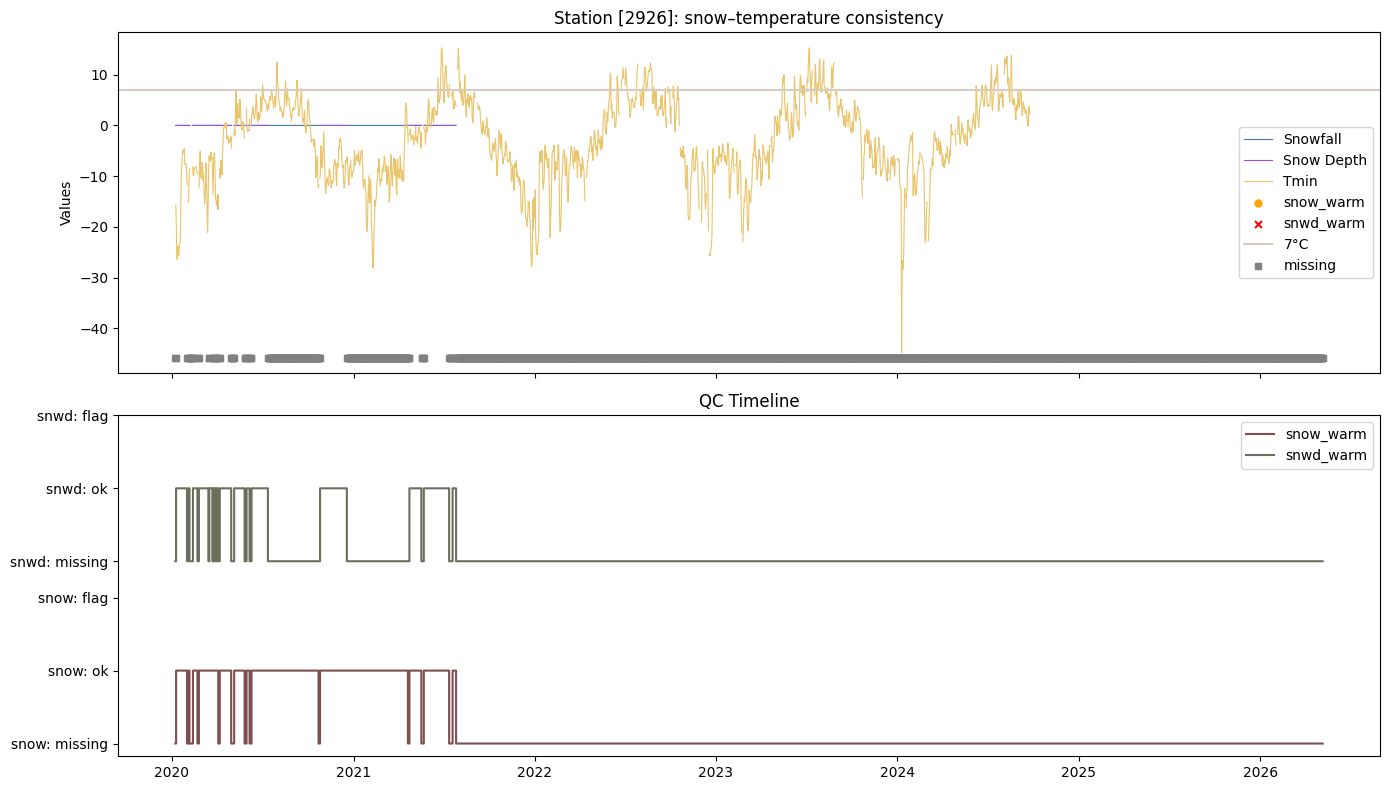

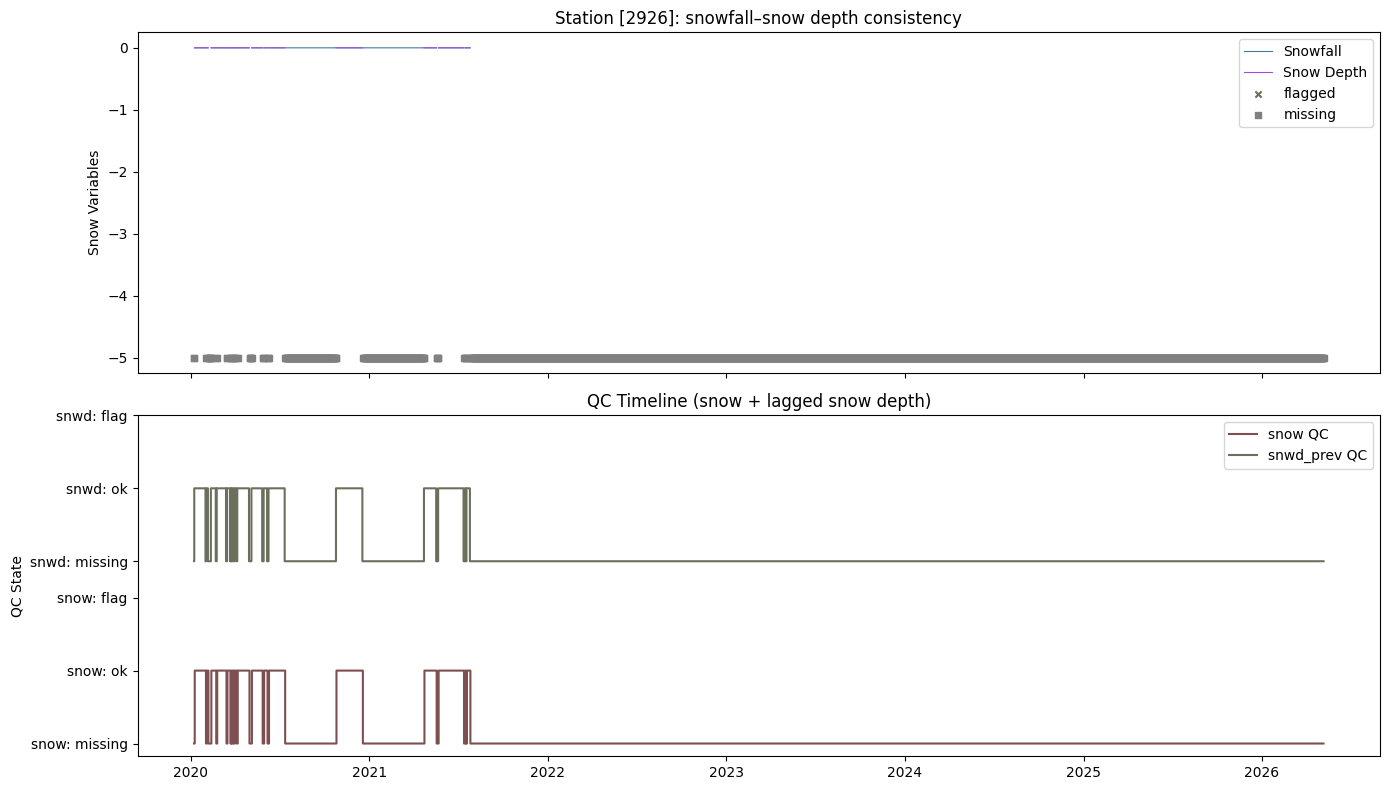

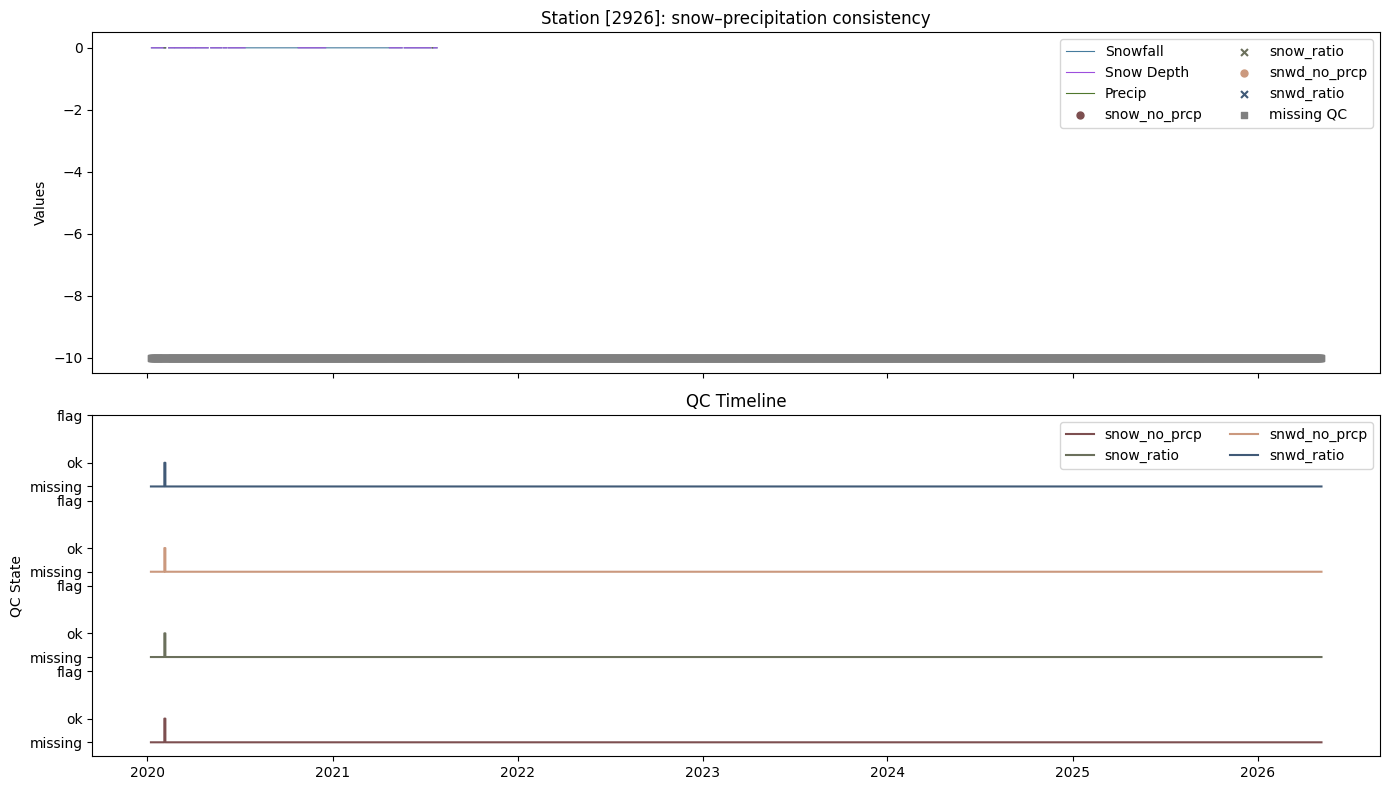

In [55]:
from visualizaion_func import *
from func_run_qc_pipeline import *

value_cols = ["temp", "tmin", "tmax", "precip", "snw_fall", "snw_dpth"]
color_map = {
    "temp": "#f4a261",
    "tmin": "#e9c46a",
    "tmax": "#e76f51",
    "snw_fall": "#457b9d",
    "snw_dpth": "#9d4edd",
    "precip": "#4f772d",
}


daily_all = build_daily_all(df_station)

result = run_qc_result_pipeline(
    daily_all,
    value_cols
)
daily_cleaned = result["daily_cleaned"]

# --------------------------------------------------
# Plot selected diagnostics
# --------------------------------------------------
plots = None

plots = [
    "raw",
    "naught_missing",
    "range",
    "clim",
    "inttemp_tas",
    "cleaned",

    "inttemp_snow_tmin",
    "inttemp_snow_fall_dpth",
    "inttemp_snow_precip"
]

plot_station_qc(
    station_id=station_id,
    daily_all=daily_all,
    daily_cleaned=daily_cleaned,
    result=result,
    value_cols=value_cols,
    color_map=color_map,
    plots=plots
)

In [56]:
from func_inttemp_1_tas_check import inttemp_temperature_consistency

inttemp_tas_result = inttemp_temperature_consistency(daily_cleaned)

inttemp_tas_result
inttemp_tas_result[inttemp_tas_result['qc_label'] == 'bad']

,temp,tmax,tmin,precip,snw_fall,snw_dpth,flag_missing,flag_basic,flag_spike,flag_lag,flag_any,qc_label,qc_code
obs_time,,,,,,,,,,,,,
